
   ADHD 概念级别关联规则挖掘（完整版）

第一步：构建论文-概念 One-Hot 矩阵
✓ 加载数据完成，共 6551 篇论文
✓ 原始概念数: 5251
✓ 过滤后概念数: 216 (出现 ≥ 52 次)
✓ One-Hot 矩阵大小: (6551, 216)
✓ 矩阵密度: 0.0455

第三步：生成概念共现热力图
✓ 使用 25 个高频概念构建共现矩阵


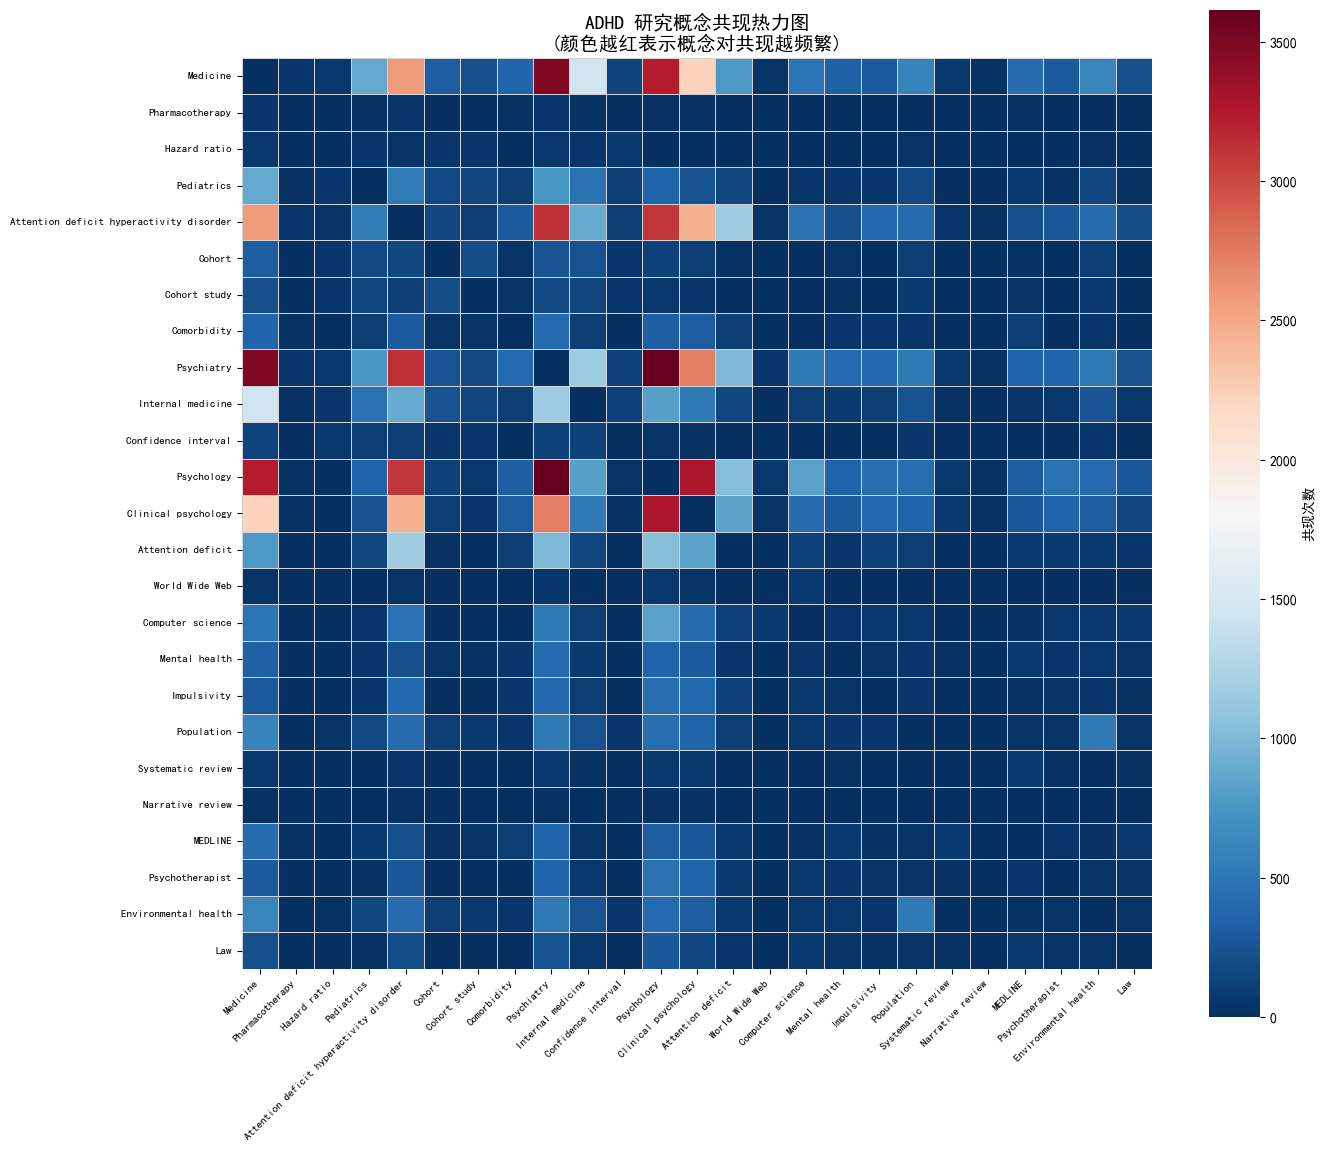

✓ 保存: adhd_cooccurrence.png

第二步：FP-Growth 关联规则挖掘
参数: support≥0.008, confidence≥0.5, lift≥1.2
✓ 正在挖掘频繁项集...
✓ 发现 4176 个频繁项集
✓ 正在生成关联规则...
✓ 生成 4273 条关联规则

--- 前10条规则 ---
Mendelian randomization, Genotype → Genetic variants | supp=0.009, conf=1.000, lift=94.942
Genetic variants → Mendelian randomization, Genotype | supp=0.009, conf=0.884, lift=94.942
Mendelian randomization, Gene → Genetic variants | supp=0.009, conf=0.968, lift=91.928
Genetic variants → Mendelian randomization, Gene | supp=0.009, conf=0.884, lift=91.928
Mendelian randomization, Biology → Genetic variants | supp=0.008, conf=0.964, lift=91.551
Genetic variants → Mendelian randomization, Biology | supp=0.008, conf=0.783, lift=91.551
Genetic variants → Mendelian randomization, Genetics | supp=0.008, conf=0.768, lift=91.490
Mendelian randomization, Genetics → Genetic variants | supp=0.008, conf=0.964, lift=91.490
Mendelian randomization → Genotype, Genetic variants | supp=0.009, conf=0.859, lift=90.779
Genotype, Genetic var

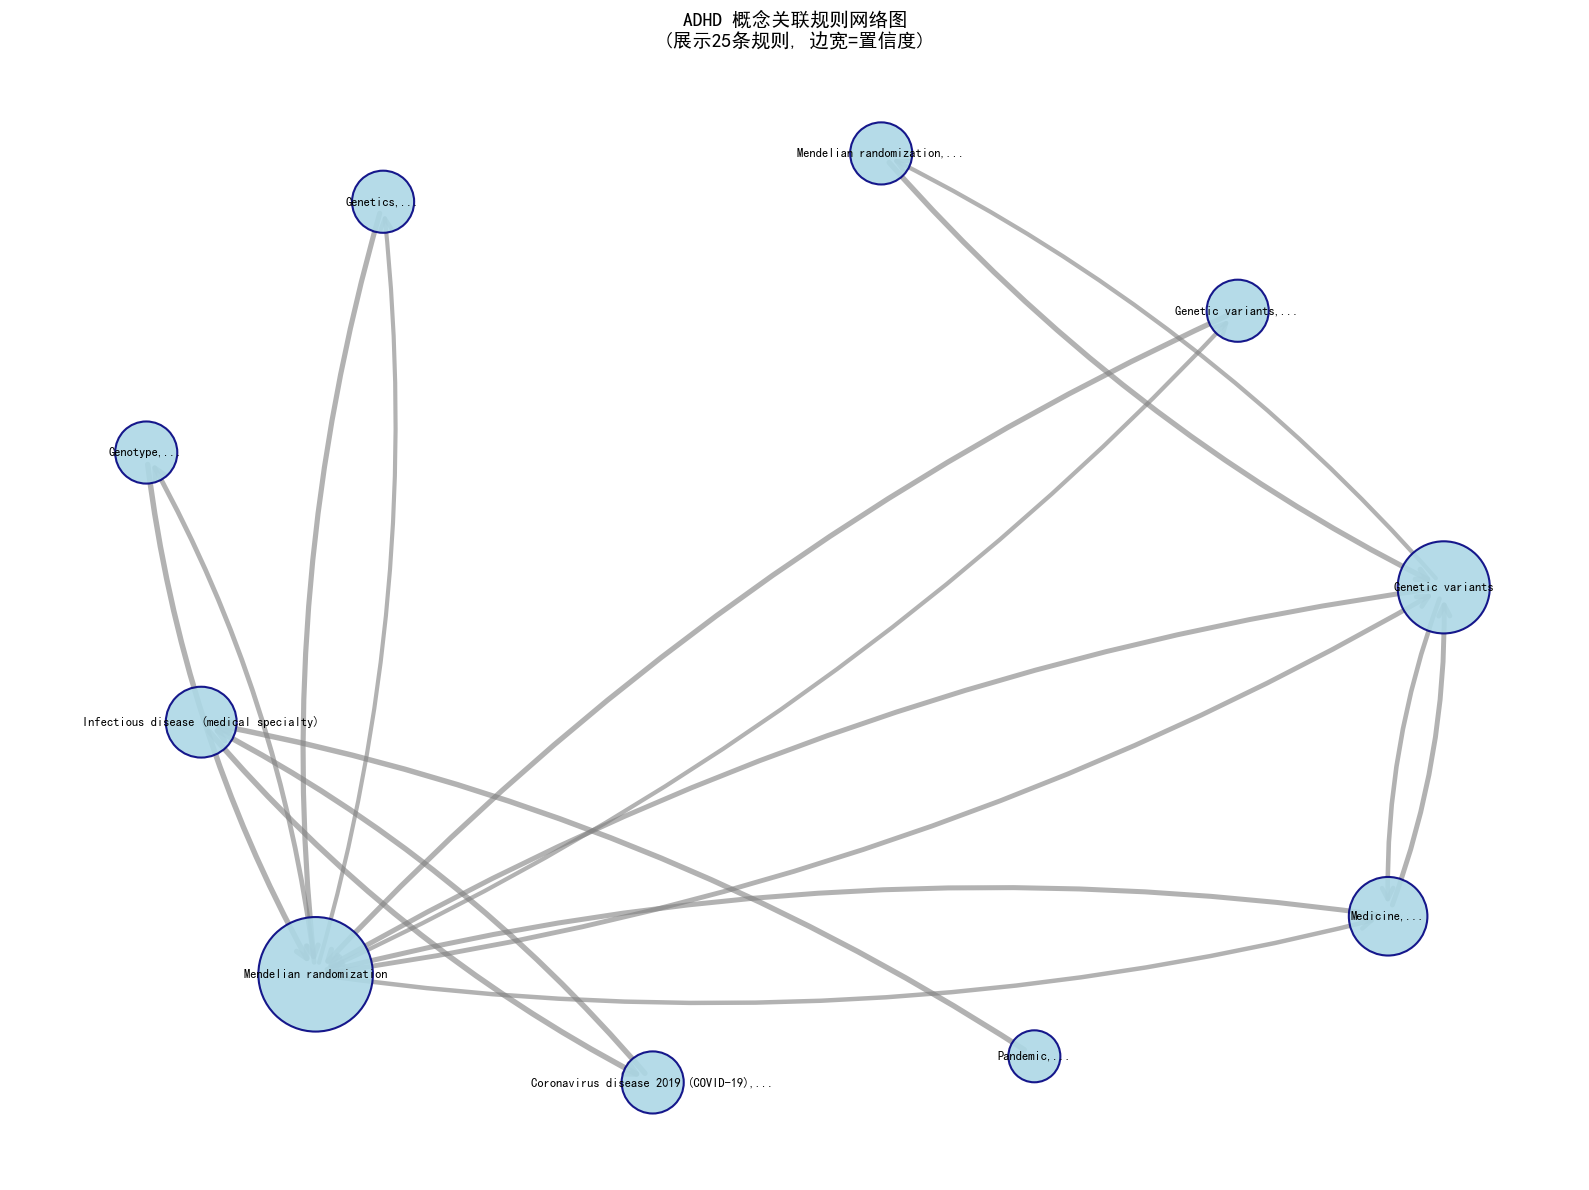

✓ 保存: adhd_network.png

生成优化版矩阵热图


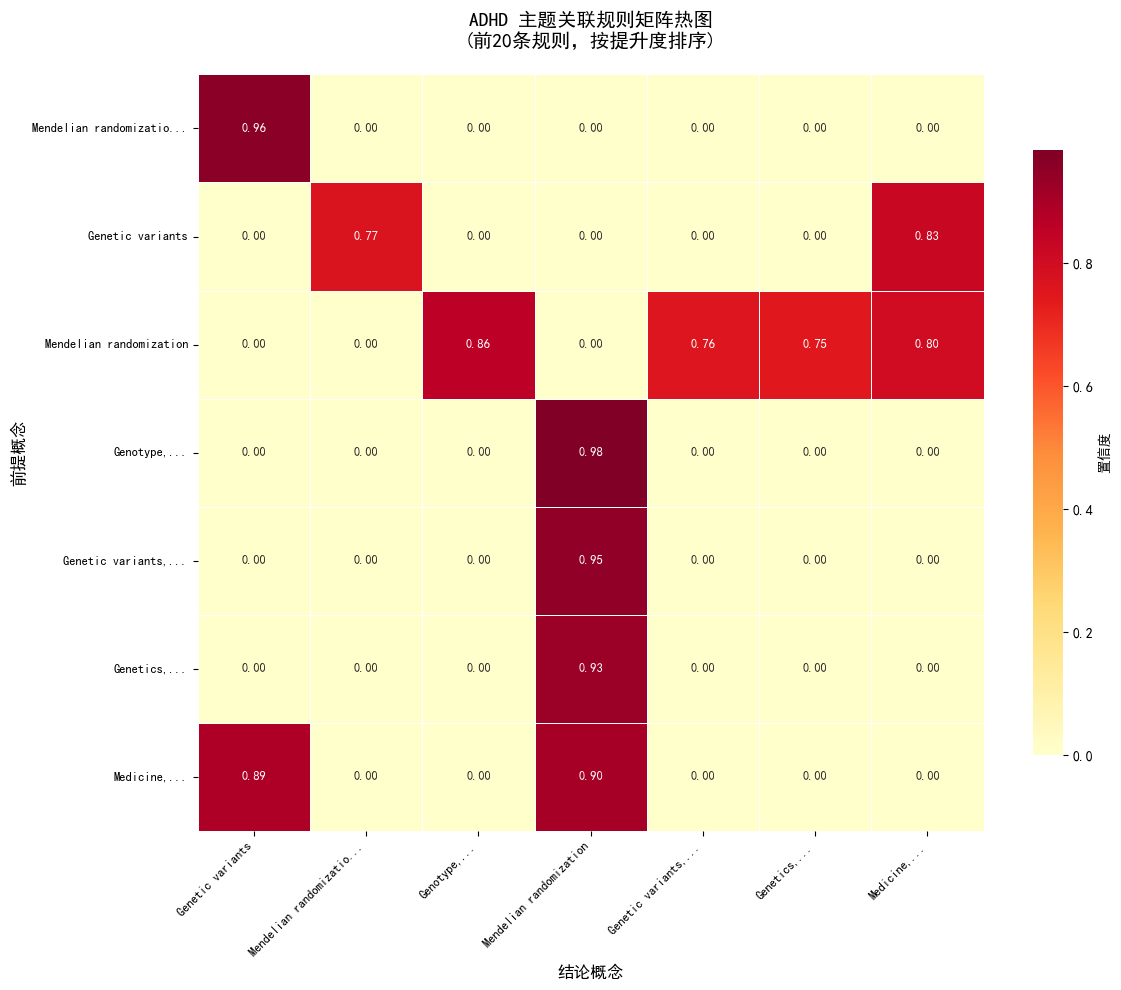

✓ 优化热图已保存: adhd_heatmap.png

--- 规则表格（可直接复制到PPT）---
前提概念                        →   结论概念                           置信度
----------------------------------------------------------------------
Mendelian randomiza...     →  Genetic variants              1.000
Genetic variants           →  Mendelian randomiza...        0.884
Mendelian randomiza...     →  Genetic variants              0.968
Genetic variants           →  Mendelian randomiza...        0.884
Mendelian randomiza...     →  Genetic variants              0.964
Genetic variants           →  Mendelian randomiza...        0.783
Genetic variants           →  Mendelian randomiza...        0.768
Mendelian randomiza...     →  Genetic variants              0.964
Mendelian randomiza...     →  Genotype                      0.859
Genotype                   →  Mendelian randomiza...        0.984

第六步：生成气泡图


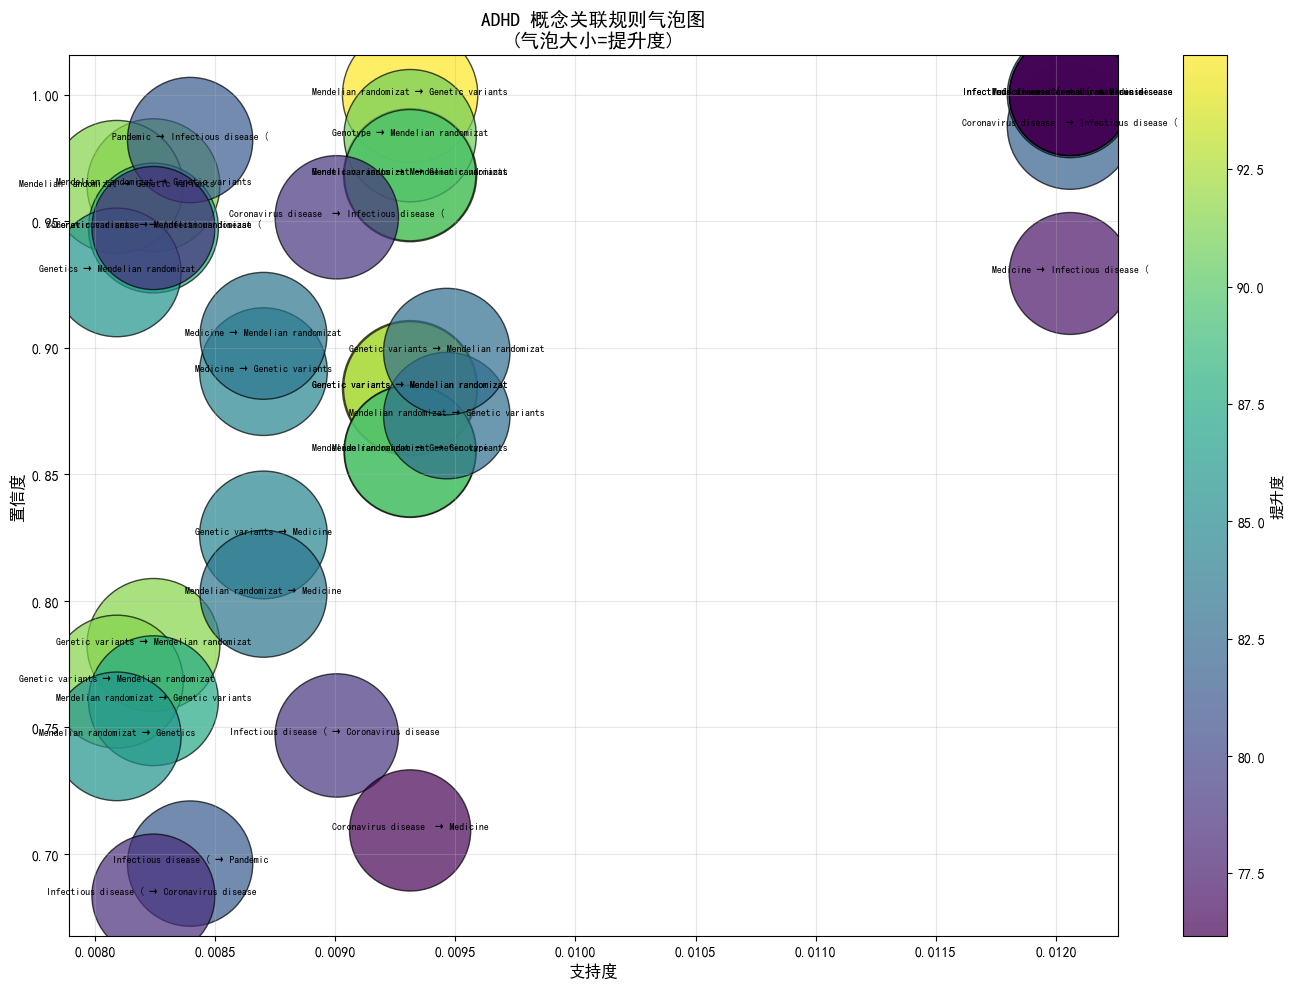

✓ 保存: adhd_bubble.png

第七步：生成平行坐标图


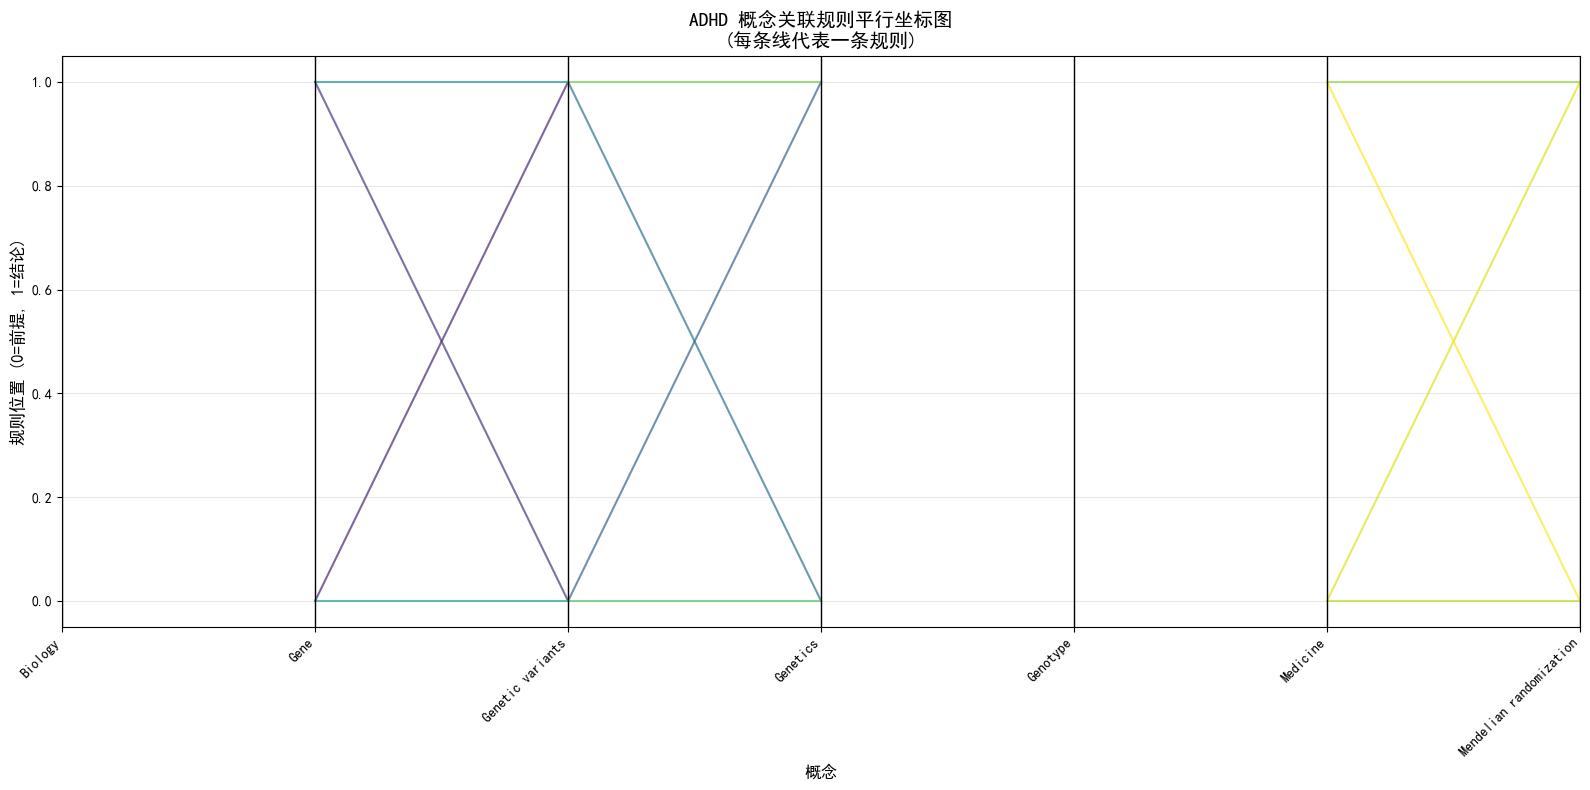

✓ 保存: adhd_parallel.png

第八步：生成桑基图


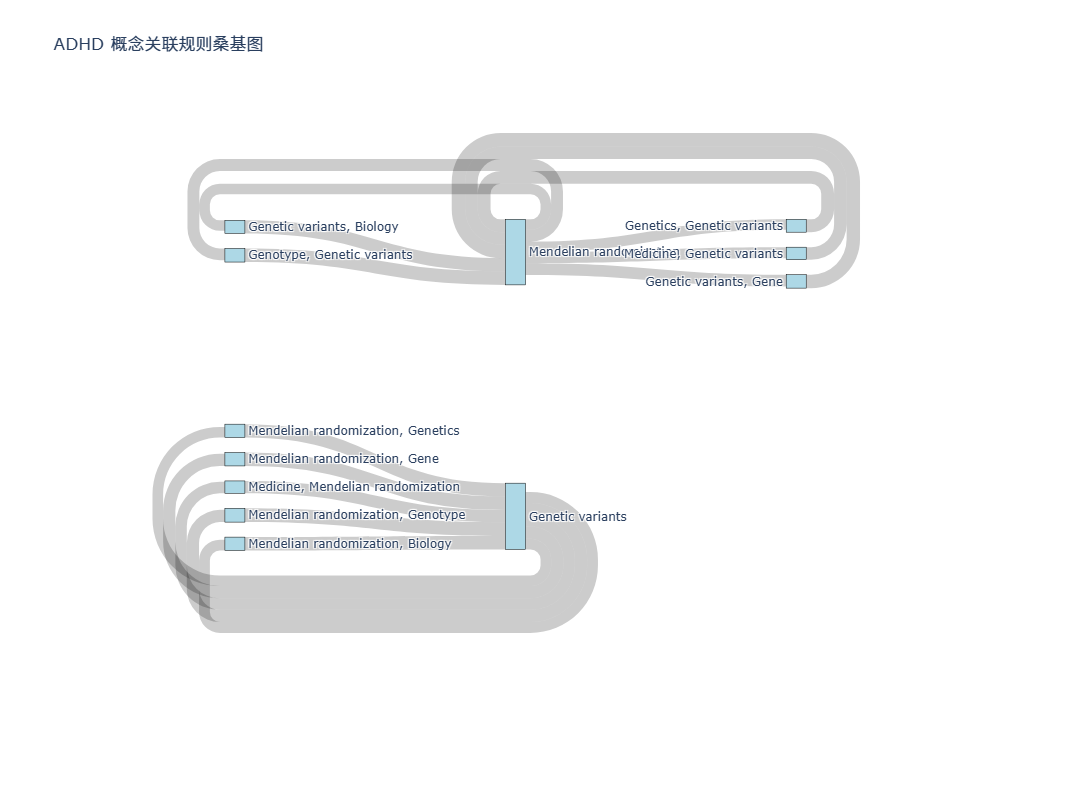

✓ 保存: adhd_sankey.html

第九步：生成词云图


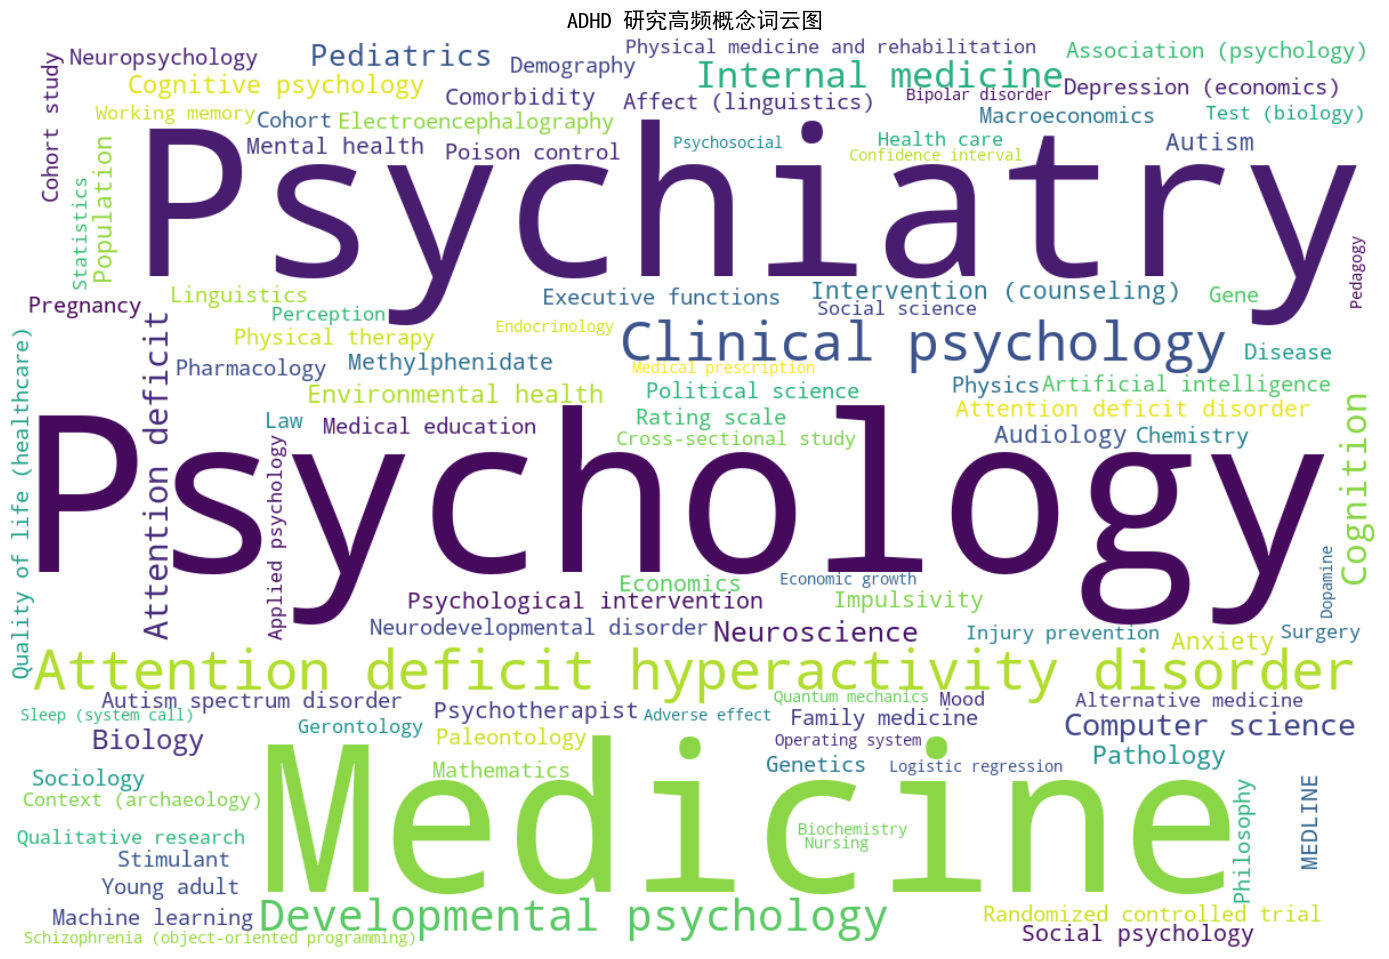

✓ 保存: adhd_wordcloud.png

第十步：生成规则质量分布图


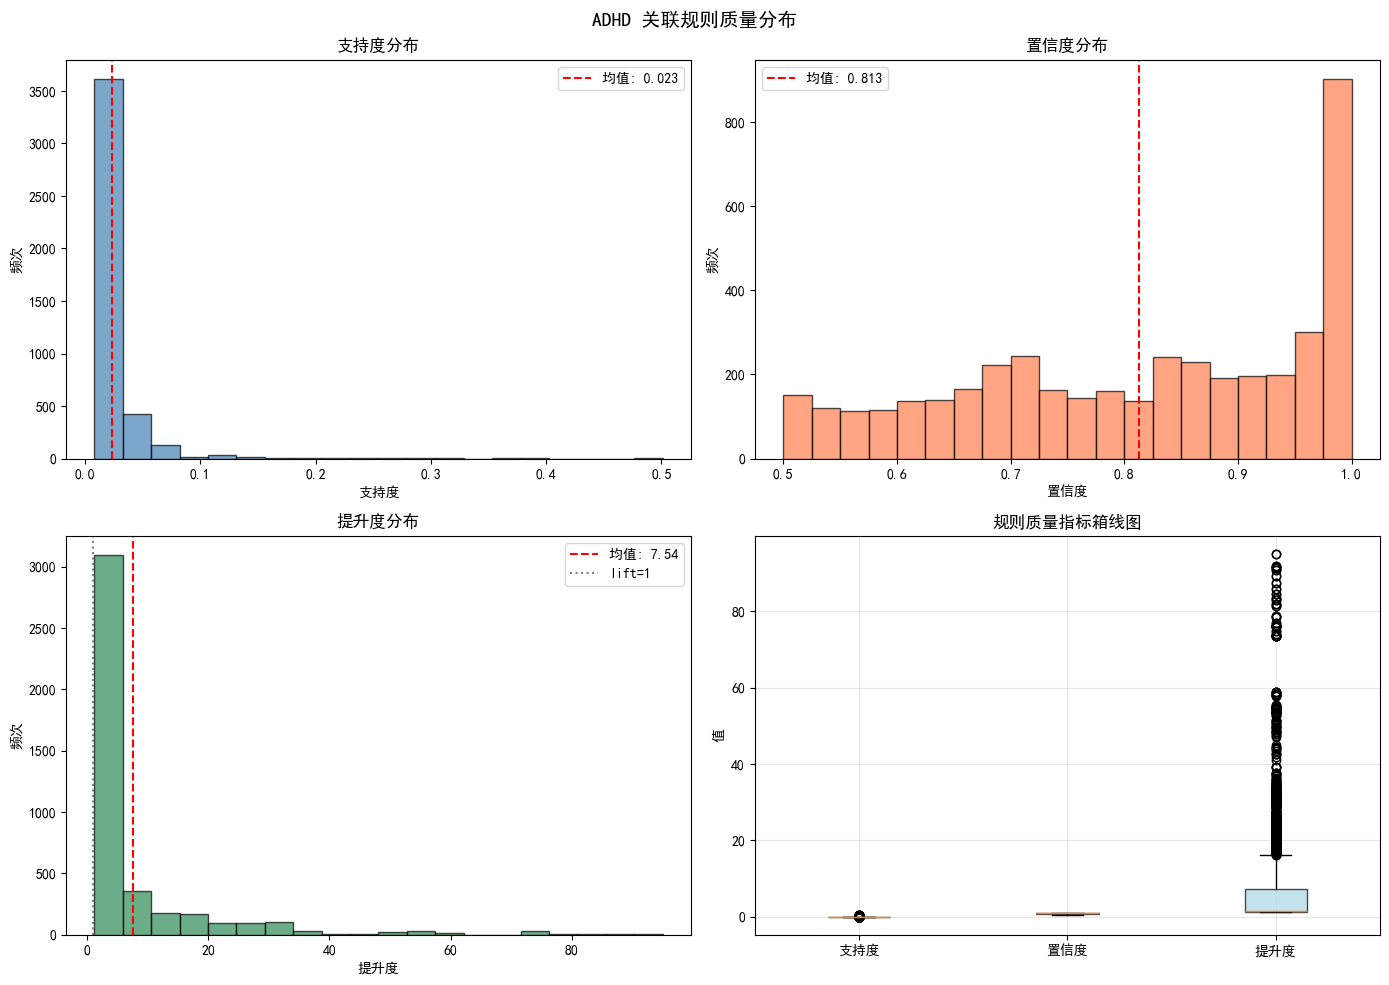

✓ 保存: adhd_rule_distribution.png

第十一步：生成规则长度分析图


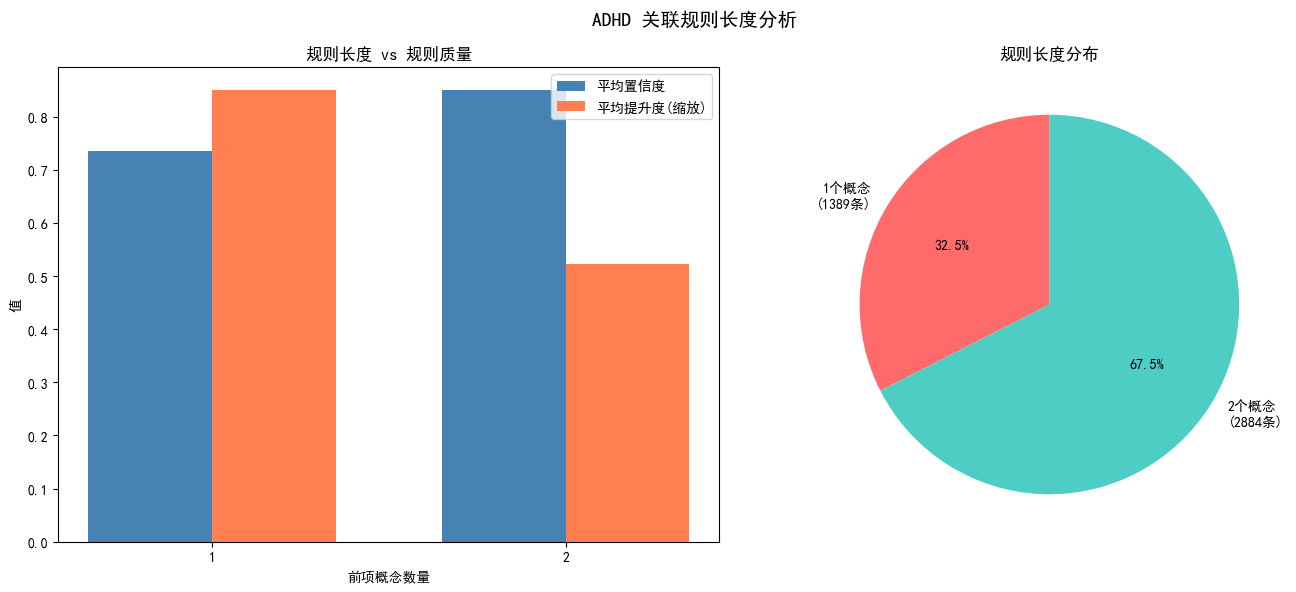

✓ 保存: adhd_rule_length.png

分析完成！统计摘要
📊 总论文数: 6551
📊 有效概念数: 216
📊 频繁项集: 4176
📊 关联规则: 4273

📈 规则质量:
   平均支持度: 0.0231
   平均置信度: 0.8128
   平均提升度: 7.5432

✅ 所有分析完成！输出文件清单：
📁 规则表: adhd_rules.csv
📁 共现分析: adhd_cooccurrence.png (新增)
📁 基础可视化: adhd_network.png, adhd_heatmap.png, adhd_bubble.png, adhd_parallel.png, adhd_sankey.html
📁 补充可视化: adhd_wordcloud.png, adhd_rule_distribution.png, adhd_rule_length.png


In [3]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 第一部分：数据加载与主题 One-Hot 编码
# ============================================================

def build_concept_matrix(file_path, min_support=0.008):
    """
    从 concepts 列构建论文-概念 One-Hot 矩阵
    """
    print("=" * 60)
    print("第一步：构建论文-概念 One-Hot 矩阵")
    print("=" * 60)
    
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    print(f"✓ 加载数据完成，共 {len(df)} 篇论文")
    
    # 提取所有概念和交易数据（用于共现分析）
    all_concepts = []
    concept_counts = {}
    transactions = []  # 新增：存储每篇论文的概念列表
    
    for concepts_str in df['concepts'].dropna():
        trans = []
        for c in str(concepts_str).split(';'):
            c = c.strip()
            all_concepts.append(c)
            concept_counts[c] = concept_counts.get(c, 0) + 1
            trans.append(c)
        transactions.append(trans)
    
    # 过滤稀有概念
    n_papers = len(df)
    threshold = max(2, int(n_papers * min_support))
    frequent_concepts = [c for c, cnt in concept_counts.items() if cnt >= threshold]
    
    print(f"✓ 原始概念数: {len(concept_counts)}")
    print(f"✓ 过滤后概念数: {len(frequent_concepts)} (出现 ≥ {threshold} 次)")
    
    # 构建 One-Hot 矩阵
    onehot_data = []
    for idx, concepts_str in enumerate(df['concepts']):
        row = {c: 0 for c in frequent_concepts}
        if pd.notna(concepts_str):
            for c in str(concepts_str).split(';'):
                c = c.strip()
                if c in frequent_concepts:
                    row[c] = 1
        row['paper_id'] = df.iloc[idx]['paper_id']
        onehot_data.append(row)
    
    onehot_df = pd.DataFrame(onehot_data)
    onehot_df = onehot_df.set_index('paper_id')
    
    print(f"✓ One-Hot 矩阵大小: {onehot_df.shape}")
    print(f"✓ 矩阵密度: {onehot_df.sum().sum() / onehot_df.size:.4f}")
    
    return onehot_df, df, transactions, concept_counts


# ============================================================
# 第二部分：FP-Growth 关联规则挖掘
# ============================================================

def mine_rules(onehot_df, min_support=0.008, min_confidence=0.5, min_lift=1.2):
    """
    挖掘关联规则
    """
    print("\n" + "=" * 60)
    print("第二步：FP-Growth 关联规则挖掘")
    print("=" * 60)
    print(f"参数: support≥{min_support}, confidence≥{min_confidence}, lift≥{min_lift}")
    
    # 转换为布尔类型
    boolean_df = onehot_df.astype(bool)
    
    # 挖掘频繁项集
    print("✓ 正在挖掘频繁项集...")
    frequent_itemsets = fpgrowth(boolean_df, min_support=min_support, 
                                  use_colnames=True, max_len=3)
    
    print(f"✓ 发现 {len(frequent_itemsets)} 个频繁项集")
    
    if len(frequent_itemsets) == 0:
        print("⚠ 未发现频繁项集，请降低 min_support")
        return pd.DataFrame(), frequent_itemsets
    
    # 生成规则
    print("✓ 正在生成关联规则...")
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=min_lift)
    
    # 过滤
    rules = rules[rules['confidence'] >= min_confidence]
    rules = rules[rules['antecedents'].apply(len) <= 2]
    
    # 排序
    rules = rules.sort_values('lift', ascending=False)
    
    print(f"✓ 生成 {len(rules)} 条关联规则")
    
    if len(rules) > 0:
        print("\n--- 前10条规则 ---")
        for i, row in rules.head(10).iterrows():
            ante = ', '.join(list(row['antecedents']))
            cons = ', '.join(list(row['consequents']))
            print(f"{ante} → {cons} | supp={row['support']:.3f}, conf={row['confidence']:.3f}, lift={row['lift']:.3f}")
    
    return rules, frequent_itemsets


# ============================================================
# 第三部分：共现热力图
# ============================================================

def plot_cooccurrence_heatmap(transactions, concept_freq, output_path='adhd_cooccurrence.png',
                               freq_threshold=5, top_n=25, figsize=(14, 12)):
    """
    生成概念共现热力图
    """
    print("\n" + "=" * 60)
    print("第三步：生成概念共现热力图")
    print("=" * 60)
    
    # 筛选高频概念
    freq_series = pd.Series(concept_freq)
    frequent_concepts = freq_series[freq_series > freq_threshold].index.tolist()
    
    if len(frequent_concepts) > top_n:
        frequent_concepts = frequent_concepts[:top_n]
    
    if len(frequent_concepts) < 3:
        print(f"⚠ 高频概念数量不足（{len(frequent_concepts)} < 3），无法生成热力图")
        return None
    
    print(f"✓ 使用 {len(frequent_concepts)} 个高频概念构建共现矩阵")
    
    # 构建共现矩阵
    cooccur_matrix = pd.DataFrame(0, index=frequent_concepts, columns=frequent_concepts)
    
    for transaction in transactions:
        trans_filtered = [c for c in transaction if c in frequent_concepts]
        for i, c1 in enumerate(trans_filtered):
            for c2 in trans_filtered[i+1:]:
                cooccur_matrix.loc[c1, c2] += 1
                cooccur_matrix.loc[c2, c1] += 1
    
    # 绘制热力图
    plt.figure(figsize=figsize)
    
    sns.heatmap(cooccur_matrix, 
                cmap='RdBu_r',
                annot=False,
                cbar_kws={'label': '共现次数'},
                linewidths=0.5,
                linecolor='lightgray',
                square=True)
    
    plt.title('ADHD 研究概念共现热力图\n(颜色越红表示概念对共现越频繁)', 
              fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 保存: {output_path}")
    
    plt.close()
    return cooccur_matrix


# ============================================================
# 第四部分：基础可视化 - 有向网络图
# ============================================================

def plot_network(rules, top_n=30, min_lift=1.3, save_path='adhd_network.png'):
    """
    有向网络图
    """
    print("\n" + "=" * 60)
    print("第四步：生成有向网络图")
    print("=" * 60)
    
    filtered = rules[rules['lift'] >= min_lift].head(top_n)
    if len(filtered) == 0:
        filtered = rules.head(top_n)
    
    G = nx.DiGraph()
    
    for _, rule in filtered.iterrows():
        ante = list(rule['antecedents'])[0] if len(rule['antecedents']) == 1 else f"{list(rule['antecedents'])[0]},..."
        cons = list(rule['consequents'])[0] if len(rule['consequents']) == 1 else f"{list(rule['consequents'])[0]},..."
        G.add_edge(ante, cons, weight=rule['confidence'], lift=rule['lift'])
    
    plt.figure(figsize=(16, 12))
    pos = nx.spring_layout(G, k=3, seed=42)
    
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    edge_widths = [w * 4 for w in edge_weights]
    node_sizes = [G.degree(n) * 600 + 800 for n in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue', 
                           edgecolors='navy', linewidths=1.5, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', 
                           alpha=0.6, arrows=True, arrowsize=20, 
                           arrowstyle='->', connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    
    plt.title(f'ADHD 概念关联规则网络图\n(展示{len(filtered)}条规则, 边宽=置信度)', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 保存: {save_path}")


# ============================================================
# 第五部分：基础可视化 - 矩阵热图
# ============================================================

def plot_heatmap(rules, top_n=25, save_path='adhd_heatmap.png'):
    """
    矩阵热图
    """
    print("\n" + "=" * 60)
    print("第五步：生成关联规则矩阵热图")
    print("=" * 60)
    
    top_rules = rules.head(top_n).copy()
    top_rules['ante'] = top_rules['antecedents'].apply(lambda x: list(x)[0])
    top_rules['cons'] = top_rules['consequents'].apply(lambda x: list(x)[0])
    
    ants = top_rules['ante'].unique()
    cons = top_rules['cons'].unique()
    matrix = pd.DataFrame(0, index=ants, columns=cons)
    
    for _, row in top_rules.iterrows():
        matrix.loc[row['ante'], row['cons']] = row['confidence']
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrRd', 
                cbar_kws={'label': '置信度'})
    plt.title(f'ADHD 概念关联规则热图\n(前{top_n}条规则)', fontsize=14)
    plt.xlabel('结论概念', fontsize=12)
    plt.ylabel('前提概念', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 保存: {save_path}")


# ============================================================
# 第六部分：基础可视化 - 气泡图
# ============================================================

def plot_bubble(rules, top_n=40, save_path='adhd_bubble.png'):
    """
    气泡图
    """
    print("\n" + "=" * 60)
    print("第六步：生成气泡图")
    print("=" * 60)
    
    top_rules = rules.head(top_n).copy()
    top_rules['rule'] = top_rules.apply(
        lambda x: f"{list(x['antecedents'])[0][:20]} → {list(x['consequents'])[0][:20]}", axis=1)
    
    plt.figure(figsize=(14, 10))
    scatter = plt.scatter(top_rules['support'], top_rules['confidence'], 
                          s=top_rules['lift'] * 100, c=top_rules['lift'], 
                          cmap='viridis', alpha=0.7, edgecolors='black')
    
    for i, row in top_rules.iterrows():
        plt.annotate(row['rule'], (row['support'], row['confidence']), 
                     fontsize=7, ha='center', va='bottom')
    
    cbar = plt.colorbar(scatter)
    cbar.set_label('提升度', fontsize=11)
    plt.xlabel('支持度', fontsize=12)
    plt.ylabel('置信度', fontsize=12)
    plt.title(f'ADHD 概念关联规则气泡图\n(气泡大小=提升度)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 保存: {save_path}")


# ============================================================
# 第九部分：补充可视化 - 词云图
# ============================================================

def plot_wordcloud(concept_freq, save_path='adhd_wordcloud.png'):
    """
    词云图
    """
    print("\n" + "=" * 60)
    print("第九步：生成词云图")
    print("=" * 60)
    
    try:
        from wordcloud import WordCloud
        
        wordcloud = WordCloud(
            width=1200, 
            height=800,
            background_color='white',
            colormap='viridis',
            max_words=100,
            relative_scaling=0.5
        ).generate_from_frequencies(concept_freq)
        
        plt.figure(figsize=(14, 10))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('ADHD 研究高频概念词云图', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ 保存: {save_path}")
        
    except ImportError:
        print("⚠ wordcloud 未安装，跳过词云图")

def plot_heatmap(rules, top_n=12, save_path='adhd_heatmap.png'):
    print("\n" + "=" * 60)
    print("生成优化版矩阵热图")
    print("=" * 60)
    
    # 取前 top_n 条规则
    top_rules = rules.head(top_n).copy()
    
    # 提取前项和后项（只取第一个概念，因为你的规则主要是 1→1）
    top_rules['ante'] = top_rules['antecedents'].apply(
        lambda x: list(x)[0] if len(x) == 1 else f"{list(x)[0]},...")
    top_rules['cons'] = top_rules['consequents'].apply(
        lambda x: list(x)[0] if len(x) == 1 else f"{list(x)[0]},...")
    
    # 缩短概念名称（适合PPT显示）
    def shorten_name(name, max_len=25):
        if len(name) > max_len:
            # 保留前 max_len-3 个字符加...
            return name[:max_len-3] + "..."
        return name
    
    top_rules['ante_short'] = top_rules['ante'].apply(shorten_name)
    top_rules['cons_short'] = top_rules['cons'].apply(shorten_name)
    
    # 获取唯一值（保持顺序）
    antecedents = top_rules['ante_short'].tolist()
    consequents = top_rules['cons_short'].tolist()
    
    # 去重并保持顺序
    unique_ante = []
    for a in antecedents:
        if a not in unique_ante:
            unique_ante.append(a)
    unique_cons = []
    for c in consequents:
        if c not in unique_cons:
            unique_cons.append(c)
    
    # 构建矩阵
    matrix = pd.DataFrame(0, index=unique_ante, columns=unique_cons)
    for _, row in top_rules.iterrows():
        a_short = shorten_name(row['ante'])
        c_short = shorten_name(row['cons'])
        if a_short in matrix.index and c_short in matrix.columns:
            matrix.loc[a_short, c_short] = row['confidence']
    
    # 绘图 - 增大尺寸
    plt.figure(figsize=(12, 10))
    
    # 绘制热图，添加数值标注
    ax = sns.heatmap(matrix, 
                     annot=True,           # 显示数值
                     fmt='.2f',            # 两位小数
                     cmap='YlOrRd',        # 黄橙红色系
                     cbar_kws={'label': '置信度', 'shrink': 0.8},
                     square=False,
                     linewidths=0.5,
                     linecolor='white',
                     annot_kws={'size': 9})  # 数值字体大小
    
    # 设置标题
    plt.title(f'ADHD 主题关联规则矩阵热图\n(前{top_n}条规则，按提升度排序)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('结论概念', fontsize=12)
    plt.ylabel('前提概念', fontsize=12)
    
    # 优化标签旋转
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    
    # 调整布局
    plt.tight_layout()
    
    # 保存
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 优化热图已保存: {save_path}")
    
    # 同时打印表格版本（方便PPT使用）
    print("\n--- 规则表格（可直接复制到PPT）---")
    print(f"{'前提概念':<25} {'→':^5} {'结论概念':<25} {'置信度':>8}")
    print("-" * 70)
    for _, row in top_rules.head(10).iterrows():
        ante = shorten_name(list(row['antecedents'])[0], 22)
        cons = shorten_name(list(row['consequents'])[0], 22)
        print(f"{ante:<25}  →  {cons:<25}  {row['confidence']:>8.3f}")
    
    return matrix

# ============================================================
# 第十部分：补充可视化 - 规则分布图
# ============================================================

def plot_rule_distribution(rules, save_path='adhd_rule_distribution.png'):
    """
    规则质量分布图
    """
    print("\n" + "=" * 60)
    print("第十步：生成规则质量分布图")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].hist(rules['support'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(rules['support'].mean(), color='red', linestyle='--', label=f'均值: {rules["support"].mean():.3f}')
    axes[0, 0].set_xlabel('支持度')
    axes[0, 0].set_ylabel('频次')
    axes[0, 0].set_title('支持度分布')
    axes[0, 0].legend()
    
    axes[0, 1].hist(rules['confidence'], bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(rules['confidence'].mean(), color='red', linestyle='--', label=f'均值: {rules["confidence"].mean():.3f}')
    axes[0, 1].set_xlabel('置信度')
    axes[0, 1].set_ylabel('频次')
    axes[0, 1].set_title('置信度分布')
    axes[0, 1].legend()
    
    axes[1, 0].hist(rules['lift'], bins=20, color='seagreen', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(rules['lift'].mean(), color='red', linestyle='--', label=f'均值: {rules["lift"].mean():.2f}')
    axes[1, 0].axvline(1.0, color='gray', linestyle=':', label='lift=1')
    axes[1, 0].set_xlabel('提升度')
    axes[1, 0].set_ylabel('频次')
    axes[1, 0].set_title('提升度分布')
    axes[1, 0].legend()
    
    data_to_plot = [rules['support'], rules['confidence'], rules['lift']]
    axes[1, 1].boxplot(data_to_plot, labels=['支持度', '置信度', '提升度'], 
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[1, 1].set_ylabel('值')
    axes[1, 1].set_title('规则质量指标箱线图')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('ADHD 关联规则质量分布', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 保存: {save_path}")


# ============================================================
# 第十一部分：补充可视化 - 规则长度分析图
# ============================================================

def plot_rule_length_analysis(rules, save_path='adhd_rule_length.png'):
    """
    规则长度分析图
    """
    print("\n" + "=" * 60)
    print("第十一步：生成规则长度分析图")
    print("=" * 60)
    
    rules_copy = rules.copy()
    rules_copy['ante_len'] = rules_copy['antecedents'].apply(len)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ante_len_stats = rules_copy.groupby('ante_len').agg({
        'confidence': 'mean',
        'lift': 'mean'
    }).reset_index()
    
    x = ante_len_stats['ante_len']
    width = 0.35
    
    axes[0].bar(x - width/2, ante_len_stats['confidence'], width, label='平均置信度', color='steelblue')
    axes[0].bar(x + width/2, ante_len_stats['lift'] / max(ante_len_stats['lift']) * max(ante_len_stats['confidence']), 
                width, label='平均提升度(缩放)', color='coral')
    axes[0].set_xlabel('前项概念数量')
    axes[0].set_ylabel('值')
    axes[0].set_title('规则长度 vs 规则质量')
    axes[0].legend()
    axes[0].set_xticks(x)
    
    len_counts = rules_copy['ante_len'].value_counts().sort_index()
    axes[1].pie(len_counts.values, labels=[f'{k}个概念\n({v}条)' for k, v in len_counts.items()],
                autopct='%1.1f%%', startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    axes[1].set_title('规则长度分布')
    
    plt.suptitle('ADHD 关联规则长度分析', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ 保存: {save_path}")


# ============================================================
# 第十二部分：导出规则表
# ============================================================

def export_rules(rules, save_path='adhd_rules.csv'):
    """
    导出规则表
    """
    print("\n" + "=" * 60)
    print("第十二步：导出规则表")
    print("=" * 60)
    
    rules_export = rules.copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: '; '.join(list(x)))
    rules_export['consequents'] = rules_export['consequents'].apply(lambda x: '; '.join(list(x)))
    
    rules_export[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_csv(
        save_path, index=False, encoding='utf-8-sig')
    
    print(f"✓ 保存: {save_path} (共{len(rules_export)}条规则)")


# ============================================================
# 主函数
# ============================================================

def main():
    # ========== 请修改为你的文件路径 ==========
    DATA_PATH = r"E:\小组作业\ADHD_热点聚类结果.csv"
    # ========================================
    
    # 参数设置
    MIN_SUPPORT = 0.008      # 0.8% 的概念出现率
    MIN_CONFIDENCE = 0.5     # 50% 置信度
    MIN_LIFT = 1.2           # 有意义的最小提升度
    
    print("\n" + "=" * 60)
    print("   ADHD 概念级别关联规则挖掘（完整版）")
    print("=" * 60 + "\n")
    
    # 1. 构建矩阵（同时获取交易数据和概念频率）
    onehot_df, df, transactions, concept_freq = build_concept_matrix(DATA_PATH, min_support=MIN_SUPPORT)
    
    if onehot_df.shape[1] < 5:
        print("⚠ 概念数量太少，尝试降低 min_support")
        onehot_df, df, transactions, concept_freq = build_concept_matrix(DATA_PATH, min_support=MIN_SUPPORT/2)
    
    # 2. 生成共现热力图（新增）
    plot_cooccurrence_heatmap(transactions, concept_freq, 
                               output_path='adhd_cooccurrence.png',
                               freq_threshold=10, top_n=25)
    
    # 3. 挖掘规则
    rules, freq = mine_rules(onehot_df, MIN_SUPPORT, MIN_CONFIDENCE, MIN_LIFT)
    
    if len(rules) == 0:
        print("\n⚠ 未生成规则，尝试更低的参数...")
        rules, freq = mine_rules(onehot_df, MIN_SUPPORT/2, MIN_CONFIDENCE-0.1, MIN_LIFT-0.2)
    
    if len(rules) > 0:
        # 导出规则表
        export_rules(rules, 'adhd_rules.csv')
        
        # 基础可视化
        plot_network(rules, top_n=25, min_lift=1.3, save_path='adhd_network.png')
        plot_heatmap(rules, top_n=20, save_path='adhd_heatmap.png')
        plot_bubble(rules, top_n=35, save_path='adhd_bubble.png')
        plot_parallel_coords(rules, top_n=20, save_path='adhd_parallel.png')
        plot_sankey(rules, top_n=20, save_path='adhd_sankey.html')
        
        # 补充可视化
        plot_wordcloud(concept_freq, save_path='adhd_wordcloud.png')
        plot_rule_distribution(rules, save_path='adhd_rule_distribution.png')
        plot_rule_length_analysis(rules, save_path='adhd_rule_length.png')
        
        # 统计摘要
        print("\n" + "=" * 60)
        print("分析完成！统计摘要")
        print("=" * 60)
        print(f"📊 总论文数: {len(df)}")
        print(f"📊 有效概念数: {onehot_df.shape[1]}")
        print(f"📊 频繁项集: {len(freq)}")
        print(f"📊 关联规则: {len(rules)}")
        print(f"\n📈 规则质量:")
        print(f"   平均支持度: {rules['support'].mean():.4f}")
        print(f"   平均置信度: {rules['confidence'].mean():.4f}")
        print(f"   平均提升度: {rules['lift'].mean():.4f}")
        
        print("\n" + "=" * 60)
        print("✅ 所有分析完成！输出文件清单：")
        print("=" * 60)
        print("📁 规则表: adhd_rules.csv")
        print("📁 共现分析: adhd_cooccurrence.png (新增)")
        print("📁 基础可视化: adhd_network.png, adhd_heatmap.png, adhd_bubble.png, adhd_parallel.png, adhd_sankey.html")
        print("📁 补充可视化: adhd_wordcloud.png, adhd_rule_distribution.png, adhd_rule_length.png")
        
    else:
        print("\n❌ 仍未生成规则，请检查数据或进一步降低参数")


if __name__ == "__main__":
    main()